### Deep learning model training.
#### max accuracy:
|model|miou(max)|oa(max)|update_time|pretrained|    
|----|----|----|----|----|
|U2Net+efficientnet_b0|93.3%|96.0%|202603|True| 
|U2Net+mobilenetv3_large_100|93.1%|96.2%|20260406|True|
|U2Net+resnet50|93.4%|96.5%|2026.4.7|True|
|U2Net+swinv2|93.2%|96.7%|2026.5.4|True|
|||||    


### conclusions:   
1. model training from pretrained parameters better than scrath.    
2. model with backbone better than unet.


In [1]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
import time
import torch
import random
import pandas as pd
import torch.nn as nn
from glob import glob
from notebooks import config
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.imgShow import imsShow
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise
from utils.dataloader import read_scenes 
from utils.metrics import oa_binary, miou_binary
from utils.dataloader import SceneArraySet, PatchPathSet
from model import u2net_timm, u2net_swin_timm


In [2]:
patch_size = 512  ## patch size setting
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
paths_dem_tra = config.paths_dem_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 52
vali patch 512: 117


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, 
                                     paths_truth_tra, 
                                     paths_dem_tra) 


In [4]:
transforms_tra = v2.Compose([
            v2.ToImage(),
            v2.RandomCrop(size=(patch_size, patch_size)),
            v2.RandomHorizontalFlip(p=0.3),
            v2.RandomVerticalFlip(p=0.3),
            v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
            GaussianNoise(mean = 0.0, sigma_max_img=0.1, sigma_max_dem=0, p=0.3) 
            ])
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])  


In [5]:
# Create dataset instances
tra_data = SceneArraySet(scenes_arr=scenes_arr, 
                          truths_arr=truths_arr, 
                          patch_size=patch_size,
                          transforms=transforms_tra)
val_data = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)

## Create data loaders
tra_loader = torch.utils.data.DataLoader(tra_data, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=5)
val_loader = torch.utils.data.DataLoader(val_data, 
                                         batch_size=4, 
                                         shuffle=False,
                                         num_workers=5)


#### Model training

In [6]:
# model = u2net_timm(num_bands_b1=6, 
#                     num_bands_b2=1, 
#                     # backbone_name='resnet50',
#                     backbone_name='mobilenetv3_large_100',
#                     # backbone_name='efficientnet_b0',
#                     pretrained=True,
#                     )


In [7]:
model = u2net_swin_timm(num_bands_b1=6, 
                    num_bands_b2=1, 
                    backbone_name="swinv2_base_window8_256",
                    img_size=512,
                    pretrained=True,
                    ) 


In [8]:
input_tensor = torch.randn(2, 7, 512, 512)  
output = model(input_tensor)  
output.shape  


torch.Size([2, 1, 512, 512])

In [9]:
### create loss and optimizer
# criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()
# criterion = GlacierLoss(aux_weight=1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
#                                           mode='min', 
#                                           factor=0.5,
#                                           min_lr=1e-5, 
#                                           patience=10)


In [10]:
'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    # pred, aux1, aux2, aux3  = model(x)
    # loss = loss_fn(pred, y, aux1, aux2, aux3)
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
    pred = (pred > 0.5).float()  ## convert prob to binary for metric calculation
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    with torch.no_grad():
        pred = model(x)
        # if x.shape[2] > 256:  ### crop inner 256x256 for evaluation
        #     pred = v2.functional.center_crop(pred, 256)
        #     y = v2.functional.center_crop(y, 256)
    loss = loss_fn(pred, y)
    pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
    pred = (pred > 0.5).float()  ## convert prob to binary
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,                     
                    epoches, 
                    device, 
                    lr_scheduler=None):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----train the model-----'''
        model.train() 
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                            optimizer=optimizer, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        '''----- validation the model: time consuming -----'''
        model.eval()
        if (epoch+1) % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                loss, miou, oa = val_step(model=model, 
                                            loss_fn=loss_fn, 
                                            x=x_batch, 
                                            y=y_batch)
                val_loss += loss.item()
                val_miou += miou.item()
                val_oa += oa.item()
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            val_loss = val_loss/size_val_loader
            val_miou = val_miou/size_val_loader
            val_oa = val_oa/size_val_loader
            tra_loss_loops.append(tra_loss); tra_miou_loops.append(tra_miou); tra_oa_loops.append(tra_oa)
            val_loss_loops.append(val_loss); val_miou_loops.append(val_miou); val_oa_loops.append(val_oa)
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, '
                    f'val-> Loss:{val_loss:.3f},Oa:{val_oa:.3f}, Miou:{val_miou:.3f},time:{time.time()-start:.1f}s')
        else: 
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(val_loss)    ## if using ReduceLROnPlateau
        ## show the result
        if (epoch+1)%20 == 0:
            sam_index = random.randrange(len(val_data))
            patch, truth = val_data[sam_index]
            patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
            with torch.no_grad():
                pred = model(patch)
                pred = F.sigmoid(pred)  ## convert logit to prob for visualization
            if patch.shape[2] > 256:  ## zoom in for visualization if patch size > 256
                pred_val = v2.functional.center_crop(pred, 256)
                patch_val = v2.functional.center_crop(patch, 256)
                truth_val = v2.functional.center_crop(truth, 256)
            else:
                patch_val = patch
                pred_val = pred
                truth_val = truth
            ## convert to numpy and plot
            patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred = pred[0].to('cpu').detach().numpy()
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch, pred, patch_val, pred_val, truth_val], 
                    clip_list = (2,0,2,0,0),
                    img_name_list=['input_patch', 'pred', 'patch_zoom_in', 'pred_zoom_in', 'truth_zoom_in'], 
                    figsize=(15, 3))
            plt.tight_layout() 
    metrics = {'tra_loss':tra_loss_loops, 'tra_oa': tra_oa_loops, 'tra_miou': tra_miou_loops,
                'val_loss': val_loss_loops, 'val_oa': val_oa_loops, 'val_miou': val_miou_loops}
    return metrics 


Ep0: tra-> Loss:0.616,Oa:0.704,Miou:0.507,                                 time:5.0s
Ep1: tra-> Loss:0.460,Oa:0.828,Miou:0.778,                                 time:4.4s
Ep2: tra-> Loss:0.351,Oa:0.944,Miou:0.908, val-> Loss:0.376,Oa:0.902, Miou:0.834,time:7.9s
Ep3: tra-> Loss:0.359,Oa:0.873,Miou:0.840,                                 time:4.4s
Ep4: tra-> Loss:0.294,Oa:0.946,Miou:0.911,                                 time:4.5s
Ep5: tra-> Loss:0.363,Oa:0.877,Miou:0.839, val-> Loss:0.287,Oa:0.897, Miou:0.842,time:8.0s
Ep6: tra-> Loss:0.321,Oa:0.890,Miou:0.853,                                 time:4.3s
Ep7: tra-> Loss:0.321,Oa:0.867,Miou:0.830,                                 time:4.5s
Ep8: tra-> Loss:0.276,Oa:0.917,Miou:0.881, val-> Loss:0.241,Oa:0.910, Miou:0.852,time:7.8s
Ep9: tra-> Loss:0.269,Oa:0.893,Miou:0.864,                                 time:4.3s
Ep10: tra-> Loss:0.304,Oa:0.854,Miou:0.808,                                 time:4.3s
Ep11: tra-> Loss:0.226,Oa:0.933,Miou:0.899, va

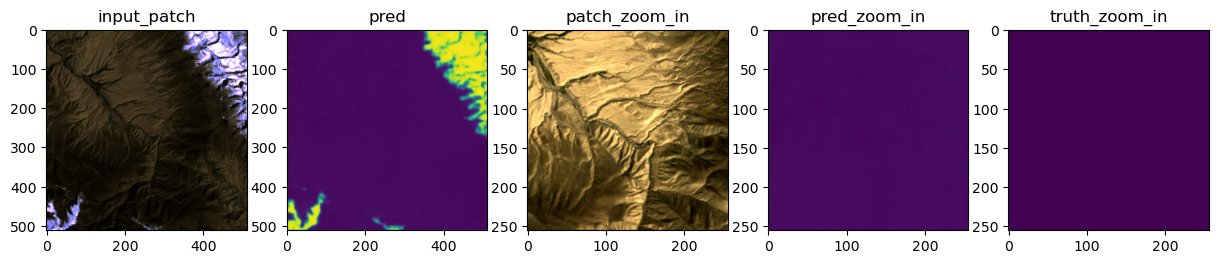

Ep20: tra-> Loss:0.149,Oa:0.954,Miou:0.928, val-> Loss:0.165,Oa:0.905, Miou:0.858,time:7.8s
Ep21: tra-> Loss:0.176,Oa:0.928,Miou:0.891,                                 time:4.5s
Ep22: tra-> Loss:0.143,Oa:0.961,Miou:0.935,                                 time:4.3s
Ep23: tra-> Loss:0.187,Oa:0.904,Miou:0.879, val-> Loss:0.142,Oa:0.933, Miou:0.862,time:7.8s
Ep24: tra-> Loss:0.167,Oa:0.909,Miou:0.878,                                 time:4.2s
Ep25: tra-> Loss:0.160,Oa:0.927,Miou:0.895,                                 time:4.7s
Ep26: tra-> Loss:0.134,Oa:0.950,Miou:0.919, val-> Loss:0.144,Oa:0.933, Miou:0.861,time:7.8s
Ep27: tra-> Loss:0.164,Oa:0.920,Miou:0.891,                                 time:4.2s
Ep28: tra-> Loss:0.162,Oa:0.912,Miou:0.867,                                 time:4.4s
Ep29: tra-> Loss:0.147,Oa:0.920,Miou:0.888, val-> Loss:0.155,Oa:0.901, Miou:0.859,time:7.8s
Ep30: tra-> Loss:0.140,Oa:0.943,Miou:0.904,                                 time:4.5s
Ep31: tra-> Loss:0.131,Oa:0.94

<Figure size 640x480 with 0 Axes>

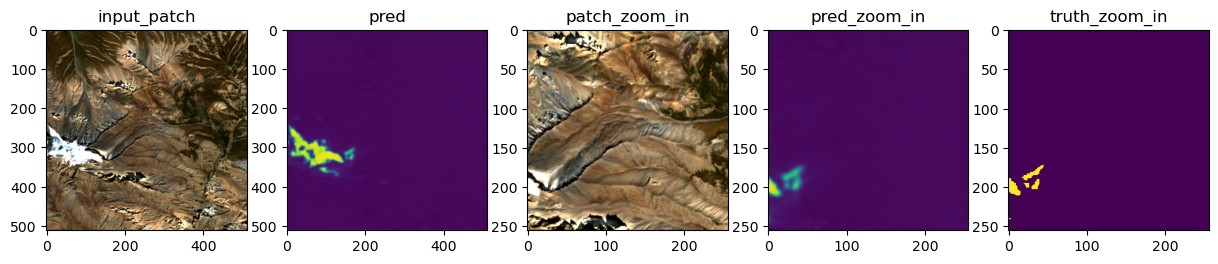

Ep40: tra-> Loss:0.124,Oa:0.955,Miou:0.913,                                 time:4.2s
Ep41: tra-> Loss:0.113,Oa:0.919,Miou:0.881, val-> Loss:0.149,Oa:0.923, Miou:0.835,time:7.6s
Ep42: tra-> Loss:0.103,Oa:0.952,Miou:0.918,                                 time:4.4s
Ep43: tra-> Loss:0.142,Oa:0.896,Miou:0.862,                                 time:4.4s
Ep44: tra-> Loss:0.100,Oa:0.975,Miou:0.937, val-> Loss:0.067,Oa:0.952, Miou:0.907,time:7.6s
Ep45: tra-> Loss:0.087,Oa:0.950,Miou:0.919,                                 time:4.4s
Ep46: tra-> Loss:0.101,Oa:0.946,Miou:0.915,                                 time:4.3s
Ep47: tra-> Loss:0.110,Oa:0.934,Miou:0.900, val-> Loss:0.071,Oa:0.941, Miou:0.908,time:7.7s
Ep48: tra-> Loss:0.108,Oa:0.948,Miou:0.910,                                 time:4.4s
Ep49: tra-> Loss:0.096,Oa:0.948,Miou:0.924,                                 time:4.2s
Ep50: tra-> Loss:0.111,Oa:0.927,Miou:0.896, val-> Loss:0.070,Oa:0.944, Miou:0.902,time:7.8s
Ep51: tra-> Loss:0.121,Oa:0.94

<Figure size 640x480 with 0 Axes>

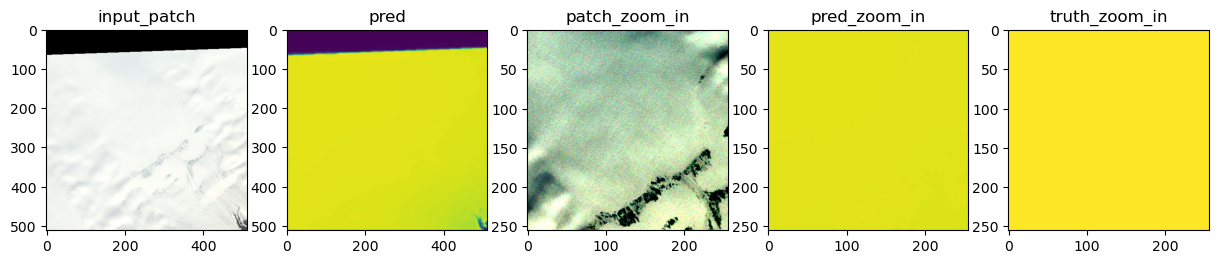

Ep60: tra-> Loss:0.088,Oa:0.951,Miou:0.923,                                 time:4.4s
Ep61: tra-> Loss:0.062,Oa:0.977,Miou:0.946,                                 time:4.4s
Ep62: tra-> Loss:0.068,Oa:0.965,Miou:0.938, val-> Loss:0.061,Oa:0.955, Miou:0.916,time:7.6s
Ep63: tra-> Loss:0.073,Oa:0.969,Miou:0.942,                                 time:4.2s
Ep64: tra-> Loss:0.069,Oa:0.979,Miou:0.958,                                 time:4.3s
Ep65: tra-> Loss:0.084,Oa:0.963,Miou:0.925, val-> Loss:0.085,Oa:0.911, Miou:0.871,time:7.8s
Ep66: tra-> Loss:0.080,Oa:0.947,Miou:0.918,                                 time:4.2s
Ep67: tra-> Loss:0.060,Oa:0.979,Miou:0.954,                                 time:4.3s
Ep68: tra-> Loss:0.063,Oa:0.976,Miou:0.947, val-> Loss:0.053,Oa:0.957, Miou:0.916,time:7.6s
Ep69: tra-> Loss:0.110,Oa:0.926,Miou:0.891,                                 time:4.3s
Ep70: tra-> Loss:0.089,Oa:0.967,Miou:0.920,                                 time:4.4s


In [ ]:
device = torch.device('cuda:0') 
metrics = train_loops(model=model, 
                epoches=300,  
                loss_fn=criterion,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [ ]:
# # model saving 
# # model_name = 'unet' 
# # model_name = 'unet_att' 
# model_name = 'u2net_cbam' 
# # model_name = 'deeplabv3plus'  
# # model_name = 'deeplabv3plus_mb2' 
# date_str = time.strftime("%Y-%m-%d-%H", time.localtime())
# date_str = date_str.replace('-', '')  ## remove '-' for file name
# # path_save = f'model/trained/{model_name}/{model_name}_weights_1.pth'
# path_save = f'model/trained/seg_models/{model_name}_weights_{date_str}.pth'
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# ## model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# ## metrics saving
# path_metrics = f'model/trained/seg_models/{model_name}_metrics_{date_str}.csv'    
# ## path_metrics = f'model/trained/{model_name}/{model_name}_metrics_1.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
